# Speciation Analysis for QMD Simulations (VASP / LAMMPS)

**Purpose:** Identify and track chemical species (molecules, clusters, isolated atoms)
in quantum molecular dynamics trajectories from VASP or LAMMPS.

**Algorithm overview:**
1. Load trajectory into an MDAnalysis Universe (supports VASP XDATCAR or LAMMPS dump).
2. At each timestep, compute pairwise distances and rank neighbors for every atom.
3. Over a sliding time window (bond-persistence criterion), identify atom pairs that
   remain mutual nearest neighbors.
4. Cluster atoms into molecules using a top-down approach (largest clusters first)
   to avoid double-counting.
5. Classify each cluster by its chemical composition and track populations over time.

**Originally developed for H₂O–H₂ systems; generalized to arbitrary multi-element systems.**

**Authors: Akash Gupta and Austin Guo, refined by Claude.**

## 1. Configuration

In [ ]:
# ---- Reference: Vibrational Periods of Common Bonds ----
# These help guide the bond_persistence_steps parameter.
# The persistence window should be at least one vibrational period
# so that transient close encounters are not mistaken for bonds.
#
# Source: https://www.chem.purdue.edu/gchelp/vibs/index.html
#         + NIST Webbook (https://webbook.nist.gov)
#
# Period = 1 / (c * wavenumber)
# where c = 2.998e10 cm/s and wavenumber is in cm^-1.
#
# --- Bonds relevant to MgSiO3 + H2 + NH3 + H2O system ---
# Elements: Mg, Si, O, N, H
#
#   Bond     Wavenumber (cm^-1)    Period (fs)    Context
#   ----     ------------------    -----------    -------
#   H-H         4342                  7.68        H2 molecule
#   O-H         3506                  9.51        H2O asymmetric stretch
#   O-H         3592                  9.29        H2O symmetric stretch
#   N-H         3337                  9.99        NH3 asymmetric stretch
#   N-H         3444                  9.68        NH3 symmetric stretch
#   Si-O        1050                 31.75        SiO4 tetrahedra (stretch)
#   Si-O         800                 41.69        SiO4 tetrahedra (bend)
#   Mg-O         500                 66.71        MgO octahedra
#   O-O         2061                 16.18        O2 molecule (if present)
#   N-N         2331                 14.30        N2 molecule (if present)
#   N-O         1876                 17.77        NO molecule
#   Si-H        2200                 15.15        SiH4 (if present)
#   Si-N         950                 35.11        Si3N4
#   Mg-H        1500                 22.24        MgH2 (if present)
#   Mg-N         600                 55.59        Mg3N2
#   Si-Si        510                 65.41        Si-Si in silicates
#   Mg-Si        ~400                ~83.4        (estimated, ionic/metallic)
#   Mg-Mg        ~300               ~111.2        (estimated, metallic)
#   H-O-H       1595                 20.91        H2O bend
#   H-N-H       1627                 20.50        NH3 bend
#   O-Si-O       450                 74.13        SiO4 bend
#
# Example: for POTIM = 0.5 fs, the Mg-O period is ~66.7 fs = ~133 steps.
# A safe bond_persistence_steps would be >= max vibrational period / POTIM.
# For this system, the slowest mode is Mg-O (~67 fs), so persistence >= 134
# steps at POTIM = 0.5 fs.

In [78]:
# ---- User Configuration ----
# Set these parameters before running the notebook.

# Run identifier (used to locate the data directory)
run_id = "a0852t"

# Base directory containing simulation run folders
data_base_dir = "/Users/akashgpt/akashgpt_local_desktop/Research/qmd_data/H2O_H2/speciation_analysis_testing_dataset"

# Input format: 'vasp' or 'lammps'
sim_format = "vasp"

# --- Trajectory selection ---
# Control which portion of the trajectory to analyze.
# Can use fractions (0.0–1.0) or absolute frame counts (integers > 1).
# Set to None to use the full trajectory from that end.
#
# Examples:
#   frame_start=0.5, frame_end=None   → last 50% of trajectory
#   frame_start=1000, frame_end=3000  → frames 1000 to 3000
#   frame_start=0.2, frame_end=0.8   → middle 60% (skip first/last 20%)
#   frame_start=None, frame_end=None  → full trajectory
frame_start_cfg = 0.75   # None, fraction (0–1), or absolute frame index
frame_end_cfg = None     # None, fraction (0–1), or absolute frame index

# --- Speciation analysis parameters ---
# Maximum cluster size to search for (number of atoms in the cluster).
# e.g., 5 means we look for clusters of up to 5 atoms (like H3O+ + extra).
max_cluster_size = 5

# Minimum cluster size (2 = dimers like H2, OH; 1 would be meaningless).
min_cluster_size = 2

# Number of nearest neighbors to consider as potential bond partners.
# This is a pre-filter: only atom pairs within this rank are considered.
neighbor_rank_cutoff = 8

# Bond persistence window: number of consecutive timesteps an atom pair must
# remain mutual nearest neighbors to be considered bonded.
# Set to 1 for instantaneous snapshot analysis (no persistence required).
# For physical bond detection, set to ~ vibrational period / dt_sim.
bond_persistence_steps = 100

# --- Output control ---
# Number of most abundant species to include in plots and data files.
# Set to None to include all detected species.
top_n_species = 10

## 2. Imports and Setup

In [79]:
from __future__ import annotations

import os
import time
import csv
from collections import defaultdict
from math import comb
from typing import Any

import numpy as np
from numpy.typing import NDArray
from scipy.stats import rankdata

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import MDAnalysis as mda
from MDAnalysis.analysis import distances

from pymatgen.io.vasp import Poscar, Incar, Xdatcar

print(f"MDAnalysis {mda.__version__}")
print(f"numpy {np.__version__}")

MDAnalysis 2.9.0
numpy 2.2.4


In [80]:
# ---- Plotting defaults ----
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (14, 8),
    'xtick.major.size': 6,
    'ytick.major.size': 6,
})

## 3. File Reading and Universe Setup

In [ ]:
def load_vasp_universe(
    run_dir: str,
) -> tuple[mda.Universe, dict[str, Any]]:
    """Load a VASP simulation into an MDAnalysis Universe.

    Reads POSCAR, INCAR, and the PDB trajectory file generated from XDATCAR.

    Args:
        run_dir: Path to the simulation run directory containing POSCAR, INCAR,
            and XDATCAR.pdb (or XDATCAR + vatic toolkit to generate PDB).

    Returns:
        A tuple of (Universe, params_dict) where params_dict contains
        simulation metadata (temperature, timestep, box dimensions, etc.).
    """
    poscar = Poscar.from_file(os.path.join(run_dir, "POSCAR"))
    incar = Incar.from_file(os.path.join(run_dir, "INCAR"))

    # Extract simulation parameters
    dt_sim = incar["POTIM"] * 1.0e-3  # Convert fs to ps (MDAnalysis uses ps)
    temperature = incar.get("TEBEG", None)
    nsw = incar.get("NSW", None)

    lattice = poscar.structure.lattice
    a_box = lattice.a
    b_box = lattice.b
    c_box = lattice.c

    # Find PDB trajectory file
    pdb_path = os.path.join(run_dir, "XDATCAR.pdb")
    if not os.path.isfile(pdb_path):
        raise FileNotFoundError(
            f"PDB trajectory not found at {pdb_path}. "
            "Generate it from XDATCAR using vatic toolkit or VASPKIT."
        )

    u = mda.Universe(pdb_path, dt=dt_sim)

    params = {
        "dt_sim_ps": dt_sim,
        "temperature_K": temperature,
        "nsw": nsw,
        "a_box": a_box,
        "b_box": b_box,
        "c_box": c_box,
        "run_dir": run_dir,
        "format": "vasp",
    }

    return u, params


def load_lammps_universe(
    run_dir: str,
) -> tuple[mda.Universe, dict[str, Any]]:
    """Load a LAMMPS simulation into an MDAnalysis Universe.

    Reads conf.lmp, in.lammps_npt_eq, and the PDB trajectory file.
    If XDATCAR does not exist, converts npt.dump to XDATCAR using ASE.

    Args:
        run_dir: Path to the simulation run directory containing conf.lmp,
            in.lammps_npt_eq, and either XDATCAR.pdb or npt.dump.

    Returns:
        A tuple of (Universe, params_dict).
    """
    import glob

    from pymatgen.io.lammps.data import LammpsData
    from pymatgen.io.lammps.inputs import LammpsInputFile

    lammps_data = LammpsData.from_file(
        os.path.join(run_dir, "conf.lmp"), atom_style="atomic"
    )
    in_lammps_matches = sorted(glob.glob(os.path.join(run_dir, "in.lammps*")))
    if not in_lammps_matches:
        raise FileNotFoundError(
            f"No LAMMPS input file matching 'in.lammps*' found in {run_dir}"
        )
    in_lammps = LammpsInputFile.from_file(in_lammps_matches[0])

    lammps_str = in_lammps.get_str()

    # Extract timestep
    dt_idx = lammps_str.find("dt equal")
    dt_sim = float(lammps_str[dt_idx:].split()[2])  # already in ps

    # Box dimensions
    a_box = lammps_data.box.to_lattice().a
    b_box = lammps_data.box.to_lattice().b
    c_box = lammps_data.box.to_lattice().c

    # Temperature
    t_idx = lammps_str.find("T1")
    temperature = float(lammps_str[t_idx:].split()[2])

    # Convert dump to XDATCAR if needed
    xdatcar_path = os.path.join(run_dir, "XDATCAR")
    if not os.path.isfile(xdatcar_path):
        from ase import io as ase_io
        dump_path = os.path.join(run_dir, "npt.dump")
        atoms = ase_io.read(dump_path, format="lammps-dump-text", index=":")
        ase_io.write(xdatcar_path, images=atoms, format="vasp-xdatcar")

    # Find or generate PDB
    pdb_path = os.path.join(run_dir, "XDATCAR.pdb")
    if not os.path.isfile(pdb_path):
        raise FileNotFoundError(
            f"PDB trajectory not found at {pdb_path}. "
            "Generate it from XDATCAR using vatic toolkit."
        )

    u = mda.Universe(pdb_path, dt=dt_sim)

    params = {
        "dt_sim_ps": dt_sim,
        "temperature_K": temperature,
        "nsw": None,
        "a_box": a_box,
        "b_box": b_box,
        "c_box": c_box,
        "run_dir": run_dir,
        "format": "lammps",
    }

    return u, params

In [82]:
def setup_atom_groups(
    u: mda.Universe,
) -> tuple[list[str], dict[str, mda.AtomGroup], list[int]]:
    """Detect atom types and create selection groups from the actual atom ordering.

    IMPORTANT: Element order and boundaries are determined from the sequential
    atom ordering in the Universe (matching the POSCAR/conf.lmp), NOT from
    alphabetical sorting. This is critical because atom indices in the
    distance matrices must map correctly to element types.

    Args:
        u: MDAnalysis Universe.

    Returns:
        A tuple of:
        - elements: List of element symbols in trajectory order (e.g., ['O', 'H']).
        - atom_groups: Dict mapping element name to AtomGroup (ordered).
        - boundaries: Cumulative atom count boundaries matching trajectory order
            (e.g., [54, 270] for 54 O then 216 H).
    """
    # Detect element boundaries from actual sequential atom ordering
    elements: list[str] = []
    boundaries: list[int] = []

    prev_type = u.atoms[0].type
    for i, atom in enumerate(u.atoms):
        if atom.type != prev_type:
            elements.append(prev_type)
            boundaries.append(i)
            prev_type = atom.type
    # Append the last element
    elements.append(prev_type)
    boundaries.append(len(u.atoms))

    # Build atom groups in the detected order
    atom_groups: dict[str, mda.AtomGroup] = {}
    for el in elements:
        atom_groups[el] = u.select_atoms(f"type {el}")

    return elements, atom_groups, boundaries

In [83]:
# ---- Load the simulation ----
run_dir = os.path.join(data_base_dir, run_id)

if sim_format == "vasp":
    u, sim_params = load_vasp_universe(run_dir)
elif sim_format == "lammps":
    u, sim_params = load_lammps_universe(run_dir)
else:
    raise ValueError(f"Unknown format: {sim_format!r}. Use 'vasp' or 'lammps'.")

elements, atom_groups, boundaries = setup_atom_groups(u)

n_atoms_total = len(u.atoms)
n_frames_total = len(u.trajectory)

# ---- Resolve trajectory selection ----
def _resolve_frame_idx(cfg_val, n_total, default):
    """Convert a frame config value to an absolute frame index.

    Args:
        cfg_val: None, a fraction (0–1 float), or an absolute frame index (int > 1).
        n_total: Total number of frames in the trajectory.
        default: Default value if cfg_val is None.

    Returns:
        Absolute frame index (int), clamped to [0, n_total].
    """
    if cfg_val is None:
        return default
    if isinstance(cfg_val, float) and 0.0 <= cfg_val <= 1.0:
        return int(cfg_val * n_total)
    return max(0, min(int(cfg_val), n_total))

frame_start = _resolve_frame_idx(frame_start_cfg, n_frames_total, 0)
frame_end = _resolve_frame_idx(frame_end_cfg, n_frames_total, n_frames_total)

if frame_start >= frame_end:
    raise ValueError(
        f"Invalid frame range: start={frame_start} >= end={frame_end}. "
        f"Check frame_start_cfg={frame_start_cfg!r} and frame_end_cfg={frame_end_cfg!r}."
    )

n_frames_analyze = frame_end - frame_start

# print(f"Run ID: {run_id}")
# print(f"Format: {sim_format}")
# print(f"Temperature: {sim_params['temperature_K']} K")
# print(f"Timestep: {sim_params['dt_sim_ps']} ps ({sim_params['dt_sim_ps']*1000:.1f} fs)")
# print(f"Total atoms: {n_atoms_total}")
# print(f"Elements: {elements}")
# for el, ag in atom_groups.items():
#     print(f"  {el}: {len(ag)} atoms")
# print(f"Element boundaries: {boundaries}")
# print(f"Total frames: {n_frames_total}")
# print(f"Analyzing frames {frame_start} to {frame_end} ({n_frames_analyze} frames, "
#       f"{n_frames_analyze/n_frames_total*100:.1f}% of trajectory)")

In [84]:
# ---- Determine output directory ----
# If the notebook is run from within the simulation folder (XDATCAR, POSCAR,
# or conf.lmp present in CWD), save to ./analysis/speciation/.
# Otherwise, save to ./analysis/speciation/{run_id}/ so multiple runs
# don't collide.

_cwd = os.getcwd()
_sim_files_in_cwd = any(
    os.path.isfile(os.path.join(_cwd, f))
    for f in ("XDATCAR", "POSCAR", "INCAR", "conf.lmp", "in.lammps_npt_eq")
)

if _sim_files_in_cwd:
    output_dir = os.path.join(_cwd, "analysis", "speciation")
else:
    output_dir = os.path.join(_cwd, "analysis", "speciation", run_id)

os.makedirs(output_dir, exist_ok=True)
# print(f"Output directory: {output_dir}")

## 4. Loaded Simulation Info

In [85]:
# ---- Simulation info ----
print(f"--- Simulation ---")
print(f"  Run ID:        {run_id}")
print(f"  Format:        {sim_format.upper()} ({'VASP AIMD' if sim_format == 'vasp' else 'LAMMPS classical/reactive MD'})")
print(f"  Temperature:   {sim_params['temperature_K']} K")
print(f"  Timestep:      {sim_params['dt_sim_ps']} ps ({sim_params['dt_sim_ps']*1000:.1f} fs)")
print(f"  Box (a,b,c):   {sim_params['a_box']:.2f}, {sim_params['b_box']:.2f}, {sim_params['c_box']:.2f} Ang")
print(f"  Total atoms:   {n_atoms_total}")
print(f"  Elements:      {', '.join(f'{len(atom_groups[el])} {el}' for el in elements)}")
print(f"  Boundaries:    {boundaries}")

# ---- Trajectory selection ----
print(f"\n--- Trajectory Selection ---")
print(f"  Total frames:    {n_frames_total}")
print(f"  frame_start_cfg: {frame_start_cfg!r}  ->  frame {frame_start}")
print(f"  frame_end_cfg:   {frame_end_cfg!r}  ->  frame {frame_end}")
print(f"  Frames analyzed: {n_frames_analyze} ({n_frames_analyze/n_frames_total*100:.1f}%)")

# ---- Output directory ----
print(f"\n--- Output ---")
print(f"  {output_dir}")

--- Simulation ---
  Run ID:        a0852t
  Format:        VASP (VASP AIMD)
  Temperature:   6000 K
  Timestep:      0.0005 ps (0.5 fs)
  Box (a,b,c):   7.83, 7.83, 15.65 Ang
  Total atoms:   412
  Elements:      54 O, 358 H
  Boundaries:    [54, 412]

--- Trajectory Selection ---
  Total frames:    7408
  frame_start_cfg: 0.75  ->  frame 5556
  frame_end_cfg:   None  ->  frame 7408
  Frames analyzed: 1852 (25.0%)

--- Output ---
  /Users/akashgpt/Desktop/akashgpt_global/Academics/Research/helpful_scripts/qmd/vasp/analysis/speciation/a0852t


## 5. Speciation Analysis — Core Algorithm

In [86]:
def compute_neighbor_ranks(
    u: mda.Universe,
    frame_start: int,
    frame_end: int,
) -> tuple[NDArray[np.float32], NDArray[np.float32]]:
    """Compute ranked neighbor lists for each atom at each selected timestep.

    For each frame in [frame_start, frame_end), computes the full pairwise
    distance matrix, replaces self-distances with inf, and ranks neighbors
    by distance using scipy.stats.rankdata.

    Args:
        u: MDAnalysis Universe with loaded trajectory.
        frame_start: First frame index to analyze (inclusive).
        frame_end: Last frame index to analyze (exclusive).

    Returns:
        A tuple of:
        - closest_neighbor_list_all: Array of shape (n_atoms, n_atoms, n_frames)
            where [i, j, t] is the rank of atom j among atom i's neighbors
            at frame t. Rank 1 = nearest neighbor.
        - closest_neighbor_list_T_all: Transpose along axes 0 and 1,
            i.e., [i, j, t] = closest_neighbor_list_all[j, i, t].
    """
    n_atoms = len(u.atoms)
    n_frames = frame_end - frame_start

    # Use float32 to halve memory (ranks are small integers)
    closest_neighbor_list_all = np.zeros((n_atoms, n_atoms, n_frames), dtype=np.float32)
    closest_neighbor_list_T_all = np.zeros((n_atoms, n_atoms, n_frames), dtype=np.float32)

    t0 = time.time()
    for idx, frame_idx in enumerate(range(frame_start, frame_end)):
        if idx % 500 == 0:
            elapsed = time.time() - t0
            print(f"  Computing neighbor ranks: frame {idx}/{n_frames} ({elapsed:.1f}s)")

        u.trajectory[frame_idx]

        # Compute condensed pairwise distances (upper triangle)
        self_distances = distances.self_distance_array(
            u.atoms.positions, box=u.dimensions
        )

        # Build full symmetric distance matrix
        closest_neighbor_list_dist = np.zeros((n_atoms, n_atoms), dtype=np.float64)
        triu_idx = np.triu_indices(n_atoms, k=1)
        closest_neighbor_list_dist[triu_idx] = self_distances
        closest_neighbor_list_dist += closest_neighbor_list_dist.T  # symmetrize

        # Set diagonal (self-distance) to inf so self is never "nearest"
        np.fill_diagonal(closest_neighbor_list_dist, np.inf)

        # Rank neighbors for each atom (row-wise). Rank 1 = closest.
        closest_neighbor_list = rankdata(closest_neighbor_list_dist, axis=1).astype(np.float32)

        closest_neighbor_list_all[:, :, idx] = closest_neighbor_list
        closest_neighbor_list_T_all[:, :, idx] = closest_neighbor_list.T

    elapsed = time.time() - t0
    print(f"  Neighbor ranks computed for {n_frames} frames in {elapsed:.1f}s")

    return closest_neighbor_list_all, closest_neighbor_list_T_all

In [87]:
def mol_formula_from_counts(
    counts: tuple[int, ...],
    elements: list[str],
) -> str:
    """Convert a tuple of atom counts per element into a chemical formula string.

    Args:
        counts: Tuple of integers, one per element, giving the number of atoms
            of that element in the molecule. E.g., (1, 2) for OH2.
        elements: List of element symbols in the same order as counts.

    Returns:
        Chemical formula string, e.g., 'H2O' or 'OH' or 'H'.
    """
    formula = ""
    for count, el in zip(counts, elements):
        if count == 1:
            formula += str(el)
        elif count > 1:
            formula += f"{el}{count}"
    return formula


def identify_atom_element(
    atom_idx: int,
    boundaries: list[int],
) -> int:
    """Determine which element an atom belongs to based on its global index.

    Args:
        atom_idx: Global atom index (0-based).
        boundaries: Cumulative atom counts, e.g., [54, 270] means
            atoms 0-53 are element 0, atoms 54-269 are element 1.

    Returns:
        Element index (0-based).
    """
    for el_idx, bound in enumerate(boundaries):
        if atom_idx < bound:
            return el_idx
    raise ValueError(f"Atom index {atom_idx} exceeds boundaries {boundaries}")

In [88]:
def speciation_at_timestep(
    n_atom_cluster_or_not_t: NDArray[np.int16],
    cluster_or_not_t: NDArray[np.float64],
    n_atoms: int,
    n_elements: int,
    boundaries: list[int],
    min_cluster_size: int,
    max_cluster_size: int,
    persistence_window: int,
) -> dict[tuple[int, ...], int]:
    """Identify molecular species at a single timestep using the neighbor data.

    The algorithm works top-down from the largest cluster size to the smallest:
    1. For each target cluster size `k` (number of neighbors = k-1):
       a. Find atoms that have >= (k-1) persistent neighbors.
       b. For each such "primary" atom (not yet assigned to a cluster):
          - Find its persistent neighbors that are not yet assigned.
          - Check if each neighbor considers the primary atom its closest
            neighbor (by summed rank over the persistence window).
          - If exactly (k-1) neighbors satisfy this mutual condition,
            form a cluster and mark all atoms as assigned.
    2. Remaining unassigned atoms are counted as isolated (monatomic) species.

    Args:
        n_atom_cluster_or_not_t: Matrix (n_atoms, n_atoms) counting how many
            frames (out of the persistence window) each pair was within the
            neighbor rank cutoff.
        cluster_or_not_t: Matrix (n_atoms, n_atoms) of summed neighbor ranks
            over the persistence window. Used to determine "closest" neighbor.
        n_atoms: Total number of atoms.
        n_elements: Number of distinct element types.
        boundaries: Cumulative atom count boundaries for element identification.
        min_cluster_size: Minimum cluster size (atoms) to search for.
        max_cluster_size: Maximum cluster size (atoms) to search for.
        persistence_window: Number of timesteps in the persistence window.

    Returns:
        Dictionary mapping composition tuples (e.g., (1, 2) for 1 O + 2 H)
        to the count of that species found at this timestep.
    """
    # Identify persistent bonds: pairs that were neighbors for the full window
    n_atom_cluster_or_not_t_conditional = (n_atom_cluster_or_not_t == persistence_window)

    # For each atom, count how many persistent bond partners it has
    n_atom_cluster_or_not_t_conditional2 = np.sum(n_atom_cluster_or_not_t_conditional, axis=1)

    # List to track atoms already assigned to clusters (avoid double-counting)
    index_atoms_accounted_for: set[int] = set()
    species_counts: dict[tuple[int, ...], int] = defaultdict(int)

    # Pre-compute: mask out the diagonal in cluster_or_not_t
    # so that np.min finds the minimum rank among OTHER atoms only
    cluster_or_not_t_masked = cluster_or_not_t.copy()
    np.fill_diagonal(cluster_or_not_t_masked, np.inf)

    # Top-down: search from largest clusters to smallest
    # n_neighbors = cluster_size - 1
    for cluster_size in range(max_cluster_size, min_cluster_size - 1, -1):
        n_neighbors_needed = cluster_size - 1

        # Find candidate primary atoms: enough persistent partners AND not assigned
        candidates = np.where(n_atom_cluster_or_not_t_conditional2 >= n_neighbors_needed)[0]

        for primary in candidates:
            if primary in index_atoms_accounted_for:
                continue

            # Get this atom's persistent neighbors (not yet assigned)
            neighbor_indices = np.where(n_atom_cluster_or_not_t_conditional[primary, :])[0]
            available_neighbors = [
                nb for nb in neighbor_indices if nb not in index_atoms_accounted_for
            ]

            # Check mutual condition: the secondary atom must consider
            # the primary as its closest neighbor (min cluster_or_not_t)
            mutual_neighbors: list[int] = []
            for secondary in available_neighbors:
                # Is primary the closest neighbor for secondary?
                sec_min_rank = cluster_or_not_t_masked[secondary, :].min()
                if cluster_or_not_t_masked[secondary, primary] == sec_min_rank:
                    mutual_neighbors.append(secondary)

                if len(mutual_neighbors) == n_neighbors_needed:
                    break

            # Only form the cluster if exactly the right number of mutual
            # neighbors were found
            if len(mutual_neighbors) == n_neighbors_needed:
                # Determine composition
                cluster_atoms = [primary] + mutual_neighbors
                composition = [0] * n_elements
                for atom_idx in cluster_atoms:
                    el_idx = identify_atom_element(atom_idx, boundaries)
                    composition[el_idx] += 1

                species_key = tuple(composition)
                species_counts[species_key] += 1

                # Mark all atoms in this cluster as assigned
                index_atoms_accounted_for.update(cluster_atoms)

    # Count remaining unassigned atoms as isolated (monatomic) species
    all_atoms = set(range(n_atoms))
    unassigned = all_atoms - index_atoms_accounted_for

    # Use boundaries with a prepended 0 for range checks
    bounds_with_zero = [0] + boundaries
    for el_idx in range(n_elements):
        lo = bounds_with_zero[el_idx]
        hi = bounds_with_zero[el_idx + 1]
        n_isolated = sum(1 for a in unassigned if lo <= a < hi)
        if n_isolated > 0:
            composition = [0] * n_elements
            composition[el_idx] = 1
            species_counts[tuple(composition)] += n_isolated

    return dict(species_counts)

In [89]:
def run_speciation_analysis(
    closest_neighbor_list_all: NDArray[np.float32],
    closest_neighbor_list_T_all: NDArray[np.float32],
    n_atoms: int,
    n_elements: int,
    boundaries: list[int],
    elements: list[str],
    neighbor_rank_cutoff: int = 6,
    bond_persistence_steps: int = 1,
    min_cluster_size: int = 2,
    max_cluster_size: int = 5,
) -> list[dict[tuple[int, ...], int]]:
    """Run the full speciation analysis over all analyzed timesteps.

    For each timestep (starting from bond_persistence_steps to allow a full
    lookback window), applies the speciation algorithm.

    Args:
        closest_neighbor_list_all: Neighbor rank array (n_atoms, n_atoms, n_frames).
        closest_neighbor_list_T_all: Transposed rank array.
        n_atoms: Total number of atoms.
        n_elements: Number of element types.
        boundaries: Cumulative atom count boundaries.
        elements: List of element symbols.
        neighbor_rank_cutoff: Only consider atom pairs within this rank.
        bond_persistence_steps: Number of consecutive frames for bond persistence.
        min_cluster_size: Minimum cluster size to detect.
        max_cluster_size: Maximum cluster size to detect.

    Returns:
        List of species-count dictionaries, one per analyzed timestep.
    """
    n_frames = closest_neighbor_list_all.shape[2]

    # Pre-compute: boolean array of whether each pair is within rank cutoff
    # Shape: (n_atoms, n_atoms, n_frames) — computed once, then sliced per timestep
    print("Pre-computing n_closest_neighbors boolean array...")
    n_closest_neighbors = (closest_neighbor_list_all[:, :, :] <= neighbor_rank_cutoff)

    # Time range: need at least `bond_persistence_steps` frames of lookback
    t_start = bond_persistence_steps
    time_indices = range(t_start, n_frames)
    n_steps = len(time_indices)

    print(f"Analyzing {n_steps} timesteps (persistence window = {bond_persistence_steps})...")

    num_species_all_T: list[dict[tuple[int, ...], int]] = []
    t0 = time.time()

    for step_idx, t in enumerate(time_indices):
        if step_idx % 200 == 0:
            elapsed = time.time() - t0
            print(f"  Speciation step {step_idx}/{n_steps} ({elapsed:.1f}s)")

        # Sum the within-cutoff boolean over the persistence window
        # Result: how many frames (out of the window) each pair was neighbors
        n_atom_cluster_or_not_t = np.sum(
            n_closest_neighbors[:, :, t - bond_persistence_steps : t],
            axis=2,
            dtype=np.int16,
        )

        # Sum the actual ranks over the persistence window
        # Used to determine which neighbor is "closest on average"
        cluster_or_not_t = np.sum(
            closest_neighbor_list_all[:, :, t - bond_persistence_steps : t],
            axis=2,
            dtype=np.float64,
        )

        species = speciation_at_timestep(
            n_atom_cluster_or_not_t=n_atom_cluster_or_not_t,
            cluster_or_not_t=cluster_or_not_t,
            n_atoms=n_atoms,
            n_elements=n_elements,
            boundaries=boundaries,
            min_cluster_size=min_cluster_size,
            max_cluster_size=max_cluster_size,
            persistence_window=bond_persistence_steps,
        )

        num_species_all_T.append(species)

    elapsed = time.time() - t0
    print(f"Speciation analysis complete: {n_steps} steps in {elapsed:.1f}s")

    return num_species_all_T

## 6. Run the Analysis

In [90]:
# ---- Step 1: Compute neighbor ranks ----
print("Step 1: Computing neighbor ranks...")
closest_neighbor_list_all, closest_neighbor_list_T_all = compute_neighbor_ranks(u, frame_start, frame_end)
print(f"  closest_neighbor_list_all shape: {closest_neighbor_list_all.shape}")
print(f"  Memory: {closest_neighbor_list_all.nbytes / 1e9:.2f} GB + {closest_neighbor_list_T_all.nbytes / 1e9:.2f} GB")

Step 1: Computing neighbor ranks...
  Computing neighbor ranks: frame 0/1852 (0.0s)
  Computing neighbor ranks: frame 500/1852 (5.5s)
  Computing neighbor ranks: frame 1000/1852 (10.7s)
  Computing neighbor ranks: frame 1500/1852 (16.1s)
  Neighbor ranks computed for 1852 frames in 19.7s
  closest_neighbor_list_all shape: (412, 412, 1852)
  Memory: 1.26 GB + 1.26 GB


In [91]:
# ---- Step 2: Run speciation ----
print("Step 2: Running speciation analysis...")
num_species_all_T = run_speciation_analysis(
    closest_neighbor_list_all=closest_neighbor_list_all,
    closest_neighbor_list_T_all=closest_neighbor_list_T_all,
    n_atoms=n_atoms_total,
    n_elements=len(elements),
    boundaries=boundaries,
    elements=elements,
    neighbor_rank_cutoff=neighbor_rank_cutoff,
    bond_persistence_steps=bond_persistence_steps,
    min_cluster_size=min_cluster_size,
    max_cluster_size=max_cluster_size,
)
print(f"Analyzed {len(num_species_all_T)} timesteps")

Step 2: Running speciation analysis...
Pre-computing n_closest_neighbors boolean array...
Analyzing 1752 timesteps (persistence window = 100)...
  Speciation step 0/1752 (0.0s)
  Speciation step 200/1752 (8.5s)
  Speciation step 400/1752 (17.0s)
  Speciation step 600/1752 (25.6s)
  Speciation step 800/1752 (34.1s)
  Speciation step 1000/1752 (42.6s)
  Speciation step 1200/1752 (51.1s)
  Speciation step 1400/1752 (59.6s)
  Speciation step 1600/1752 (68.1s)
Speciation analysis complete: 1752 steps in 74.6s
Analyzed 1752 timesteps


## 7. Aggregate Results and Plot

In [92]:
def aggregate_species(
    num_species_all_T: list[dict[tuple[int, ...], int]],
    elements: list[str],
) -> tuple[NDArray[np.float64], list[str], list[tuple[int, ...]]]:
    """Convert the list of per-timestep species dictionaries into a 2D array.

    Collects all unique species keys across all timesteps and builds a
    (n_timesteps, n_species) array of counts.

    Args:
        num_species_all_T: List of dicts from run_speciation_analysis.
        elements: List of element symbols for formula generation.

    Returns:
        A tuple of:
        - counts_array: Shape (n_timesteps, n_species) array of species counts.
        - formula_labels: List of chemical formula strings for each species column.
        - species_keys: List of composition tuples corresponding to each column.
    """
    # Collect all unique species keys across all timesteps
    all_keys: set[tuple[int, ...]] = set()
    for d in num_species_all_T:
        all_keys.update(d.keys())

    # Sort keys for consistent ordering:
    # First by total atoms in species, then by composition
    species_keys = sorted(all_keys, key=lambda k: (sum(k), k))

    n_timesteps = len(num_species_all_T)
    n_species = len(species_keys)

    counts_array = np.zeros((n_timesteps, n_species), dtype=np.float64)
    for t_idx, d in enumerate(num_species_all_T):
        for s_idx, key in enumerate(species_keys):
            counts_array[t_idx, s_idx] = d.get(key, 0)

    formula_labels = [
        mol_formula_from_counts(key, elements) for key in species_keys
    ]

    return counts_array, formula_labels, species_keys


# Aggregate
counts_array, formula_labels, species_keys = aggregate_species(
    num_species_all_T, elements
)

# ---- Determine top-N species by mean abundance ----
# This selection is used for plots, summary table, and data file exports.
mean_counts = np.mean(counts_array, axis=0)
# Rank species by descending mean abundance
ranked_indices = np.argsort(mean_counts)[::-1]

if top_n_species is not None:
    top_indices = ranked_indices[:top_n_species]
else:
    top_indices = ranked_indices

# Sort the selected indices back into the original order for consistent display
top_indices = np.sort(top_indices)

top_formula_labels = [formula_labels[i] for i in top_indices]
top_species_keys = [species_keys[i] for i in top_indices]
top_counts = counts_array[:, top_indices]

n_total_species = len(formula_labels)
n_shown = len(top_indices)
print(f"Species detected: {n_total_species} total, showing top {n_shown}")
for i in top_indices:
    label = formula_labels[i]
    key = species_keys[i]
    mc = mean_counts[i]
    if mc > 0.001:
        print(f"  {label:>8s} {key}: mean = {mc:.2f} +/- {np.std(counts_array[:, i]):.2f}")

Species detected: 9 total, showing top 9
         H (0, 1): mean = 324.80 +/- 6.71
         O (1, 0): mean = 40.27 +/- 3.24
        H2 (0, 2): mean = 8.89 +/- 2.85
        OH (1, 1): mean = 11.81 +/- 2.87
        H3 (0, 3): mean = 0.24 +/- 0.46
       OH2 (1, 2): mean = 1.23 +/- 1.15
       O2H (2, 1): mean = 0.31 +/- 0.54
       OH3 (1, 3): mean = 0.03 +/- 0.18
      O2H2 (2, 2): mean = 0.01 +/- 0.11


In [93]:
# ---- Atom conservation check ----
# Verify that the total number of each element is conserved at every timestep.
for el_idx, el in enumerate(elements):
    expected = atom_groups[el].n_atoms
    # Sum: for each species, count_of_species * atoms_of_this_element_in_species
    actual_per_step = np.zeros(len(num_species_all_T))
    for s_idx, key in enumerate(species_keys):
        actual_per_step += counts_array[:, s_idx] * key[el_idx]
    
    min_actual = actual_per_step.min()
    max_actual = actual_per_step.max()
    if min_actual != expected or max_actual != expected:
        print(f"WARNING: {el} atom count not conserved! "
              f"Expected {expected}, got range [{min_actual}, {max_actual}]")
    else:
        print(f"{el}: atom conservation OK ({expected} atoms at every timestep)")

O: atom conservation OK (54 atoms at every timestep)
H: atom conservation OK (358 atoms at every timestep)


Saved: /Users/akashgpt/Desktop/akashgpt_global/Academics/Research/helpful_scripts/qmd/vasp/analysis/speciation/a0852t/species_counts_vs_time.png


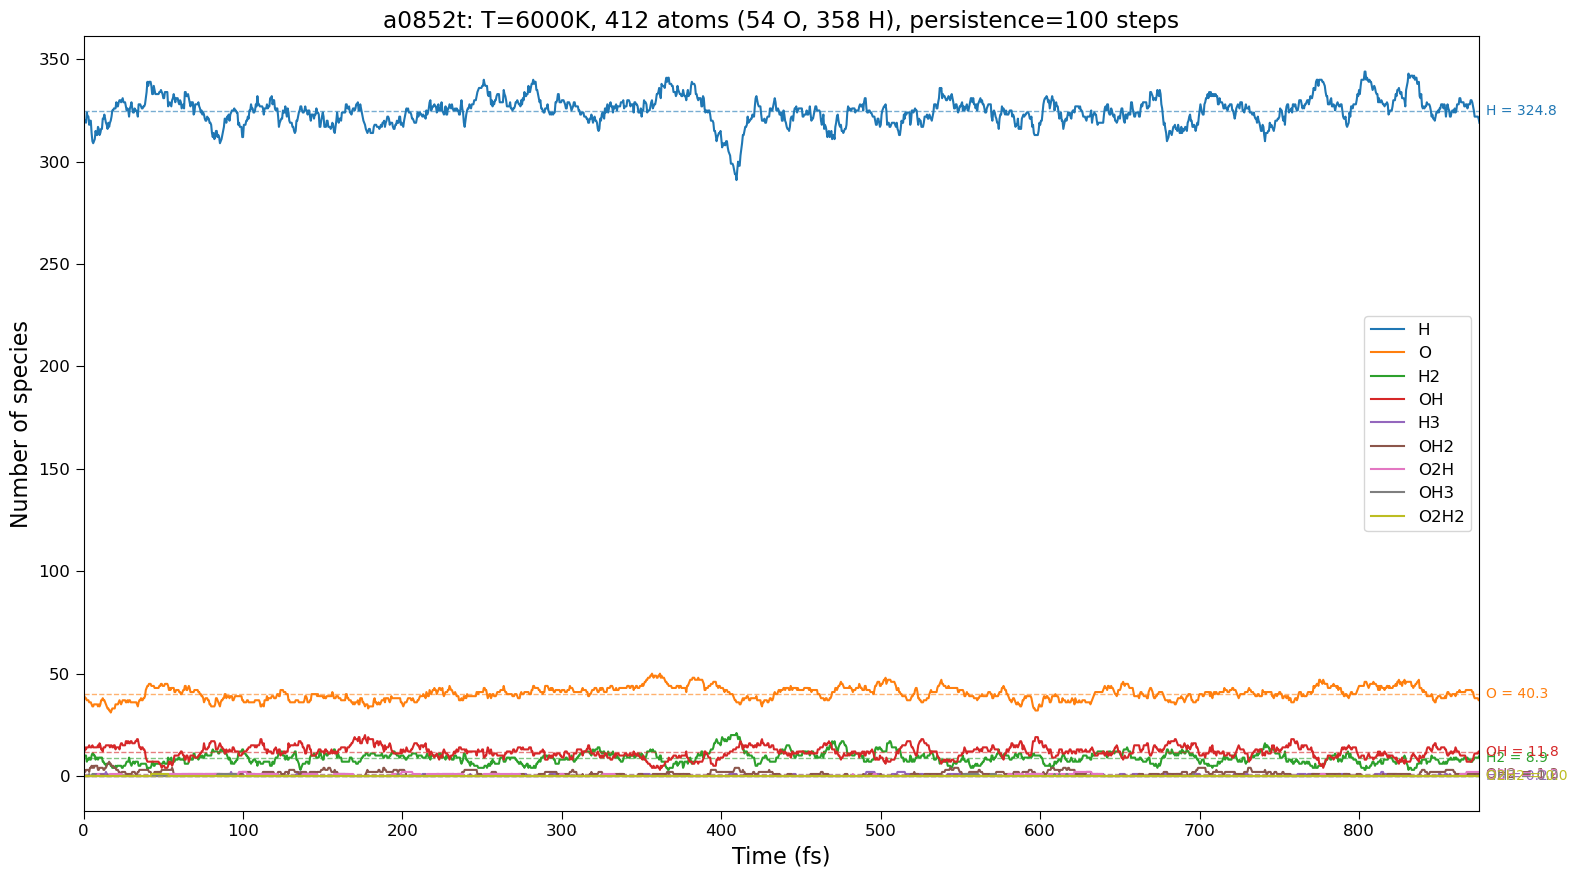

In [94]:
# ---- Plot: Species counts over time (top N) ----
dt_fs = sim_params["dt_sim_ps"] * 1000  # Convert ps to fs
time_axis = np.arange(len(num_species_all_T)) * dt_fs  # in fs

fig, ax = plt.subplots(figsize=(16, 9))

for plot_i, (label, key) in enumerate(zip(top_formula_labels, top_species_keys)):
    col_idx = species_keys.index(key)
    mean_val = mean_counts[col_idx]
    ax.plot(time_axis, counts_array[:, col_idx], label=label, color=f"C{plot_i}")
    ax.axhline(
        mean_val, color=f"C{plot_i}", linestyle="--", linewidth=1, alpha=0.6
    )
    ax.annotate(
        f"{label} = {mean_val:.1f}",
        xy=(time_axis[-1], mean_val),
        xytext=(5, 0),
        textcoords="offset points",
        color=f"C{plot_i}",
        fontsize=10,
        va="center",
    )

ax.set_xlabel("Time (fs)")
ax.set_ylabel("Number of species")
ax.set_title(
    f"{run_id}: T={sim_params['temperature_K']}K, "
    f"{n_atoms_total} atoms ({', '.join(f'{len(ag)} {el}' for el, ag in atom_groups.items())}), "
    f"persistence={bond_persistence_steps} steps"
)
ax.legend(loc="best")
ax.set_xlim(time_axis[0], time_axis[-1])
plt.tight_layout()

fig.savefig(os.path.join(output_dir, "species_counts_vs_time.png"), dpi=150)
print(f"Saved: {os.path.join(output_dir, 'species_counts_vs_time.png')}")
plt.show()

Saved: /Users/akashgpt/Desktop/akashgpt_global/Academics/Research/helpful_scripts/qmd/vasp/analysis/speciation/a0852t/species_fractions_vs_time.png


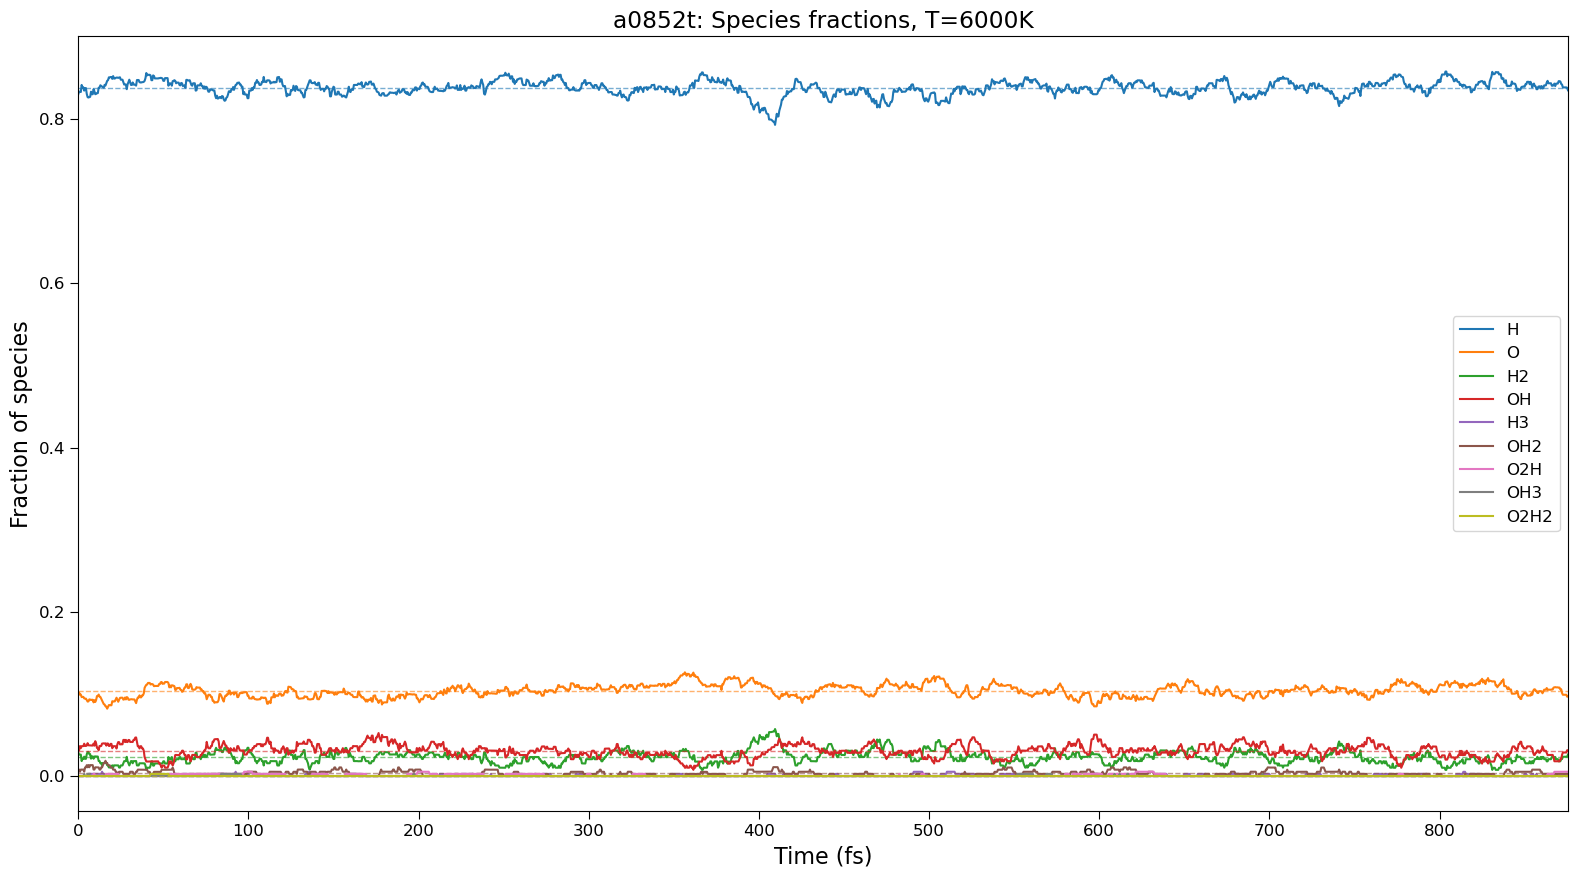

In [95]:
# ---- Plot: Species fractions over time (top N) ----
total_species = np.sum(counts_array, axis=1, keepdims=True)
# Avoid division by zero
total_species = np.where(total_species == 0, 1, total_species)
fractions = counts_array / total_species

fig, ax = plt.subplots(figsize=(16, 9))

for plot_i, (label, key) in enumerate(zip(top_formula_labels, top_species_keys)):
    col_idx = species_keys.index(key)
    mean_frac = np.mean(fractions[:, col_idx])
    ax.plot(time_axis, fractions[:, col_idx], label=label, color=f"C{plot_i}")
    ax.axhline(
        mean_frac, color=f"C{plot_i}", linestyle="--", linewidth=1, alpha=0.6
    )

ax.set_xlabel("Time (fs)")
ax.set_ylabel("Fraction of species")
ax.set_title(
    f"{run_id}: Species fractions, T={sim_params['temperature_K']}K"
)
ax.legend(loc="best")
ax.set_xlim(time_axis[0], time_axis[-1])
plt.tight_layout()

fig.savefig(os.path.join(output_dir, "species_fractions_vs_time.png"), dpi=150)
print(f"Saved: {os.path.join(output_dir, 'species_fractions_vs_time.png')}")
plt.show()

In [39]:
# ---- Summary table (top N species) ----
print(f"\n{'='*60}")
print(f"Speciation Summary for {run_id}")
print(f"T = {sim_params['temperature_K']} K")
print(f"Frames analyzed: {len(num_species_all_T)}")
print(f"Persistence window: {bond_persistence_steps} steps")
print(f"Neighbor rank cutoff: {neighbor_rank_cutoff}")
print(f"Top species shown: {n_shown} / {n_total_species}")
print(f"{'='*60}")
print(f"{'Species':>10s}  {'Mean':>8s}  {'Std':>8s}  {'Min':>6s}  {'Max':>6s}")
print(f"{'-'*50}")
for label, key in zip(top_formula_labels, top_species_keys):
    col_idx = species_keys.index(key)
    col = counts_array[:, col_idx]
    print(f"{label:>10s}  {np.mean(col):8.2f}  {np.std(col):8.2f}  {np.min(col):6.0f}  {np.max(col):6.0f}")
print(f"{'='*60}")


Speciation Summary for a08218ai
T = 1000 K
Frames analyzed: 1490
Persistence window: 100 steps
Neighbor rank cutoff: 8
Top species shown: 2 / 2
   Species      Mean       Std     Min     Max
--------------------------------------------------
        H2     54.00      0.00      54      54
       OH2     54.00      0.00      54      54


## 8. Export Results

In [40]:
# ---- Save species counts to CSV (top N) ----
csv_path = os.path.join(output_dir, "speciation_counts.csv")

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["frame"] + top_formula_labels)
    for t_idx in range(len(num_species_all_T)):
        row = [t_idx + bond_persistence_steps]
        for key in top_species_keys:
            col_idx = species_keys.index(key)
            row.append(int(counts_array[t_idx, col_idx]))
        writer.writerow(row)

print(f"Species counts saved to {csv_path}")

# ---- Save summary statistics (top N) ----
summary_path = os.path.join(output_dir, "speciation_summary.csv")

with open(summary_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["species", "composition", "mean", "std", "min", "max"])
    for label, key in zip(top_formula_labels, top_species_keys):
        col_idx = species_keys.index(key)
        col = counts_array[:, col_idx]
        writer.writerow([
            label,
            str(key),
            f"{np.mean(col):.4f}",
            f"{np.std(col):.4f}",
            f"{np.min(col):.0f}",
            f"{np.max(col):.0f}",
        ])

print(f"Summary saved to {summary_path}")

# ---- Save run info (separated into categories) ----
info_path = os.path.join(output_dir, "run_info.csv")

info_rows = [
    # -- Simulation Info --
    ("category", "simulation_info"),
    ("run_id", run_id),
    ("sim_format", sim_format),
    ("run_dir", run_dir),
    ("temperature_K", sim_params["temperature_K"]),
    ("dt_sim_fs", sim_params["dt_sim_ps"] * 1000),
    ("n_atoms_total", n_atoms_total),
    ("elements", " ".join(elements)),
    ("atoms_per_element", " ".join(f"{len(atom_groups[el])}" for el in elements)),
    ("element_boundaries", " ".join(str(b) for b in boundaries)),
    ("n_frames_total", n_frames_total),
    ("box_a", f"{sim_params['a_box']:.4f}"),
    ("box_b", f"{sim_params['b_box']:.4f}"),
    ("box_c", f"{sim_params['c_box']:.4f}"),
    # -- Reproducibility Parameters --
    ("category", "reproducibility_params"),
    ("frame_start_cfg", repr(frame_start_cfg)),
    ("frame_end_cfg", repr(frame_end_cfg)),
    ("frame_start", frame_start),
    ("frame_end", frame_end),
    ("n_frames_analyzed", n_frames_analyze),
    ("max_cluster_size", max_cluster_size),
    ("min_cluster_size", min_cluster_size),
    ("neighbor_rank_cutoff", neighbor_rank_cutoff),
    ("bond_persistence_steps", bond_persistence_steps),
    ("top_n_species", top_n_species),
    # -- Results --
    ("category", "results"),
    ("output_dir", output_dir),
    ("n_species_detected", n_total_species),
    ("n_species_shown", n_shown),
]

with open(info_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["parameter", "value"])
    writer.writerows(info_rows)

print(f"Run info saved to {info_path}")
print(f"\nAll outputs in: {output_dir}")

Species counts saved to /Users/akashgpt/Desktop/akashgpt_global/Academics/Research/helpful_scripts/qmd/vasp/analysis/speciation/a08218ai/speciation_counts.csv
Summary saved to /Users/akashgpt/Desktop/akashgpt_global/Academics/Research/helpful_scripts/qmd/vasp/analysis/speciation/a08218ai/speciation_summary.csv
Run info saved to /Users/akashgpt/Desktop/akashgpt_global/Academics/Research/helpful_scripts/qmd/vasp/analysis/speciation/a08218ai/run_info.csv

All outputs in: /Users/akashgpt/Desktop/akashgpt_global/Academics/Research/helpful_scripts/qmd/vasp/analysis/speciation/a08218ai


## 9. Run Summary

Run this cell to view a full summary of the analysis configuration, simulation
parameters, and output locations — without stepping through previous sections.

In [41]:
# ---- Print full run summary ----
# This cell can be run standalone after the notebook completes to review
# all key parameters and output paths at a glance.

print(f"{'='*65}")
print(f"  RUN SUMMARY")
print(f"{'='*65}")

# --- Simulation Info ---
print(f"\n--- Simulation Info ---")
print(f"  Run ID:          {run_id}")
print(f"  Format:          {sim_format.upper()} ({'VASP AIMD' if sim_format == 'vasp' else 'LAMMPS classical/reactive MD'})")
print(f"  Run directory:   {run_dir}")
print(f"  Temperature:     {sim_params['temperature_K']} K")
print(f"  Timestep:        {sim_params['dt_sim_ps']*1000:.1f} fs")
print(f"  Box (a,b,c):     {sim_params['a_box']:.2f}, {sim_params['b_box']:.2f}, {sim_params['c_box']:.2f} Ang")
print(f"  Total atoms:     {n_atoms_total}")
print(f"  Elements:        {', '.join(f'{len(atom_groups[el])} {el}' for el in elements)}")
print(f"  Total frames:    {n_frames_total}")

# --- Reproducibility Parameters ---
print(f"\n--- Reproducibility Parameters ---")
print(f"  frame_start_cfg: {frame_start_cfg!r}  ->  frame {frame_start}")
print(f"  frame_end_cfg:   {frame_end_cfg!r}  ->  frame {frame_end}")
print(f"  Frames analyzed: {n_frames_analyze} ({n_frames_analyze/n_frames_total*100:.1f}%)")
print(f"  Cluster size:    {min_cluster_size} to {max_cluster_size} atoms")
print(f"  Neighbor cutoff: rank <= {neighbor_rank_cutoff}")
print(f"  Persistence:     {bond_persistence_steps} steps ({bond_persistence_steps * sim_params['dt_sim_ps']*1000:.1f} fs)")
print(f"  top_n_species:   {top_n_species}")

# --- Results ---
print(f"\n--- Results ---")
print(f"  Species detected:  {n_total_species}")
print(f"  Species shown:     {n_shown}")

# --- Output ---
print(f"\n--- Output Directory ---")
print(f"  {output_dir}")
print(f"    ├── speciation_counts.csv")
print(f"    ├── speciation_summary.csv")
print(f"    ├── run_info.csv")
print(f"    ├── species_counts_vs_time.png")
print(f"    └── species_fractions_vs_time.png")
print(f"{'='*65}")

  RUN SUMMARY

--- Simulation Info ---
  Run ID:          a08218ai
  Format:          VASP (VASP AIMD)
  Run directory:   /Users/akashgpt/akashgpt_local_desktop/Research/qmd_data/H2O_H2/speciation_analysis_testing_dataset/a08218ai
  Temperature:     1000 K
  Timestep:        0.5 fs
  Box (a,b,c):     11.95, 11.95, 23.90 Ang
  Total atoms:     270
  Elements:        54 O, 216 H
  Total frames:    3179

--- Reproducibility Parameters ---
  frame_start_cfg: 0.5  ->  frame 1589
  frame_end_cfg:   None  ->  frame 3179
  Frames analyzed: 1590 (50.0%)
  Cluster size:    2 to 5 atoms
  Neighbor cutoff: rank <= 8
  Persistence:     100 steps (50.0 fs)
  top_n_species:   10

--- Results ---
  Species detected:  2
  Species shown:     2

--- Output Directory ---
  /Users/akashgpt/Desktop/akashgpt_global/Academics/Research/helpful_scripts/qmd/vasp/analysis/speciation/a08218ai
    ├── speciation_counts.csv
    ├── speciation_summary.csv
    ├── run_info.csv
    ├── species_counts_vs_time.png
    └─